In [1]:
# import libraries
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import os

from tensorflow.keras.preprocessing.image import ImageDataGenerator

from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

from sklearn.metrics import confusion_matrix, classification_report

import tensorflow as tf

Task 1: Problem Identification

This dataset represents an Image Classification problem because each image belongs to one specific category such as dent, scratch, stain, or normal. The objective of the model is to correctly classify an image into one of these predefined classes.

Image classification is appropriate for this dataset because:

1. Each image has a single label
2. The dataset is organized into category folders
3. The goal is prediction of image category rather than object localization or segmentation

The CNN model will learn visual patterns from the images and classify them into the correct defect category.

In [3]:
#DATASET EXPLORATION
dataset_path = 'images'

classes = os.listdir(dataset_path)

classes = [folder for folder in os.listdir(dataset_path) if folder != '.DS_Store']

print("Classes in Dataset:")

print(classes)

Classes in Dataset:
['dent', 'stain', 'scratch', 'normal']


In [4]:
#image counts
for category in classes:

    path = os.path.join(dataset_path, category)

    print(f"{category}: {len(os.listdir(path))} images")

dent: 120 images
stain: 120 images
scratch: 120 images
normal: 120 images


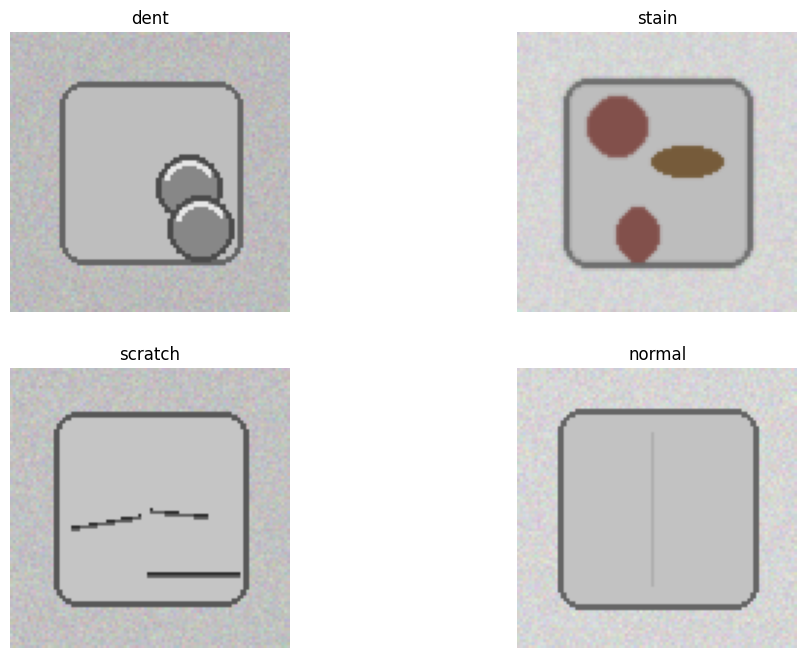

In [5]:
#sample images
from tensorflow.keras.preprocessing import image

plt.figure(figsize=(12,8))

for i, category in enumerate(classes):

    img_name = os.listdir(os.path.join(dataset_path, category))[0]

    img_path = os.path.join(dataset_path, category, img_name)

    img = image.load_img(img_path)

    plt.subplot(2,2,i+1)

    plt.imshow(img)

    plt.title(category)

    plt.axis('off')

plt.show()

In [6]:
#image dimensions
sample_image = os.path.join(

    dataset_path,

    classes[0],

    os.listdir(os.path.join(dataset_path, classes[0]))[0]

)

img = image.load_img(sample_image)

print("Image Size:", img.size)

Image Size: (96, 96)


Task 3: Image Processing

In [7]:
#processing parameters
img_height = 128

img_width = 128

batch_size = 32

In [8]:
#image generator
train_datagen = ImageDataGenerator(

    rescale=1./255,

    validation_split=0.2

)

In [9]:
#train generator
train_generator = train_datagen.flow_from_directory(

    'images',

    target_size=(img_height, img_width),

    batch_size=batch_size,

    class_mode='categorical',

    subset='training'

)

Found 384 images belonging to 4 classes.


In [10]:
#validation generator
validation_generator = train_datagen.flow_from_directory(

    'images',

    target_size=(img_height, img_width),

    batch_size=batch_size,

    class_mode='categorical',

    subset='validation'

)

Found 96 images belonging to 4 classes.


Task4: CNN Model Creation

In [11]:
model = Sequential()

In [12]:
#1st convilution layer
model.add(Conv2D(

    32,

    (3,3),

    activation='relu',

    input_shape=(128,128,3)

))

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
#add max pooling
model.add(MaxPooling2D(pool_size=(2,2)))

In [14]:
#2nd convolution block
model.add(Conv2D(

    64,

    (3,3),

    activation='relu'

))

model.add(MaxPooling2D(pool_size=(2,2)))

In [15]:
#flatten Layer
model.add(Flatten())

In [16]:
#Dense Layer
model.add(Dense(

    128,

    activation='relu'

))

In [17]:
#Dropout Layer
model.add(Dropout(0.5))

In [18]:
#Output Layer
model.add(Dense(

    4,

    activation='softmax'

))

In [19]:
#Compile Model
model.compile(

    optimizer='adam',

    loss='categorical_crossentropy',

    metrics=['accuracy']

)

In [20]:
#Model Summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

Task5: Model Training and Evaluation

In [22]:
# Train the CNN model



history = model.fit(

    train_generator,

    validation_data=validation_generator,

    epochs=10

)

Epoch 1/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 2s 111ms/step - accuracy: 0.2240 - loss: 3.0966 - val_accuracy: 0.2500 - val_loss: 1.3868
Epoch 2/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 97ms/step - accuracy: 0.3099 - loss: 1.3764 - val_accuracy: 0.2500 - val_loss: 1.3649
Epoch 3/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.3880 - loss: 1.3118 - val_accuracy: 0.4479 - val_loss: 1.2531
Epoch 4/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 99ms/step - accuracy: 0.5365 - loss: 1.1405 - val_accuracy: 0.5729 - val_loss: 1.0569
Epoch 5/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.6380 - loss: 0.9167 - val_accuracy: 0.6042 - val_loss: 0.9626
Epoch 6/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.7135 - loss: 0.8130 - val_accuracy: 0.7188 - val_loss: 0.7503
Epoch 7/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 98ms/step - accuracy: 0.7760 - loss: 0.6395 - val_accuracy: 0.7396 - val_loss: 0.5659
Epoch 8/10
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 100ms/step - accuracy: 0.8229 - loss: 0.5042 - val_accuracy: 0.7500 -

## Training Observation

The CNN model showed continuous improvement in both training and validation accuracy across epochs. Validation accuracy increased from approximately 25% to over 83%, indicating that the model successfully learned meaningful visual patterns from the defect images.

A small gap between training and validation accuracy suggests slight overfitting, which is expected in smaller image datasets, but the model still demonstrated good generalization performance.

TASK 6 — MODEL EVALUATION

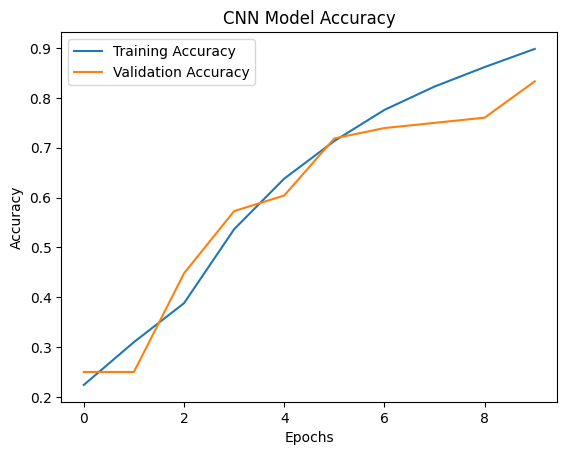

In [23]:
# Plot training and validation accuracy

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title('CNN Model Accuracy')

plt.xlabel('Epochs')

plt.ylabel('Accuracy')

plt.legend()

plt.show()

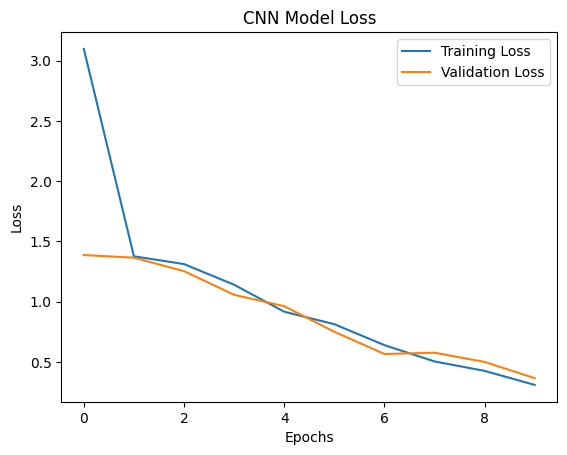

In [24]:
# Plot training and validation loss

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Model Loss')

plt.xlabel('Epochs')

plt.ylabel('Loss')

plt.legend()

plt.show()

In [25]:
# Evaluate CNN model

loss, accuracy = model.evaluate(validation_generator)

print("Validation Accuracy:", accuracy)

print("Validation Loss:", loss)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.8333 - loss: 0.3653
Validation Accuracy: 0.8333333134651184
Validation Loss: 0.36532798409461975


In [26]:
# Generate predictions

predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step


In [27]:
#True Labels
true_classes = validation_generator.classes

In [28]:
#Confusion Matrix
cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[4 9 6 5]
 [7 3 5 9]
 [6 8 6 4]
 [6 5 7 6]]


In [29]:
#Classification Report
class_labels = list(validation_generator.class_indices.keys())

print(classification_report(

    

    true_classes,

    

    predicted_classes,

    

    target_names=class_labels

))

              precision    recall  f1-score   support

        dent       0.17      0.17      0.17        24
      normal       0.12      0.12      0.12        24
     scratch       0.25      0.25      0.25        24
       stain       0.25      0.25      0.25        24

    accuracy                           0.20        96
   macro avg       0.20      0.20      0.20        96
weighted avg       0.20      0.20      0.20        96



In [31]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Create image data generator

datagen = ImageDataGenerator(

    

    rescale=1./255,

    

    validation_split=0.2

    

)
# Recreate validation generator without shuffling

validation_generator = datagen.flow_from_directory(

    

    'images',

    

    target_size=(128, 128),

    

    batch_size=32,

    

    class_mode='categorical',

    

    subset='validation',

    

    shuffle=False

    

)

Found 96 images belonging to 4 classes.


In [32]:
predictions = model.predict(validation_generator)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = validation_generator.classes

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step


In [33]:
cm = confusion_matrix(true_classes, predicted_classes)

print(cm)

[[17  0  5  2]
 [ 0 24  0  0]
 [ 6  1 17  0]
 [ 0  0  2 22]]


In [34]:
class_labels = list(validation_generator.class_indices.keys())

print(classification_report(

    

    true_classes,

    

    predicted_classes,

    

    target_names=class_labels

))

              precision    recall  f1-score   support

        dent       0.74      0.71      0.72        24
      normal       0.96      1.00      0.98        24
     scratch       0.71      0.71      0.71        24
       stain       0.92      0.92      0.92        24

    accuracy                           0.83        96
   macro avg       0.83      0.83      0.83        96
weighted avg       0.83      0.83      0.83        96



## Model Evaluation Observation

The CNN model achieved approximately 83% validation accuracy on the image dataset.

The confusion matrix shows that the model performed well on the normal and stain categories, while some confusion occurred between dent and scratch images due to visual similarity in defect patterns.

Overall, the CNN successfully learned meaningful visual features from the dataset and demonstrated good classification performance.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step


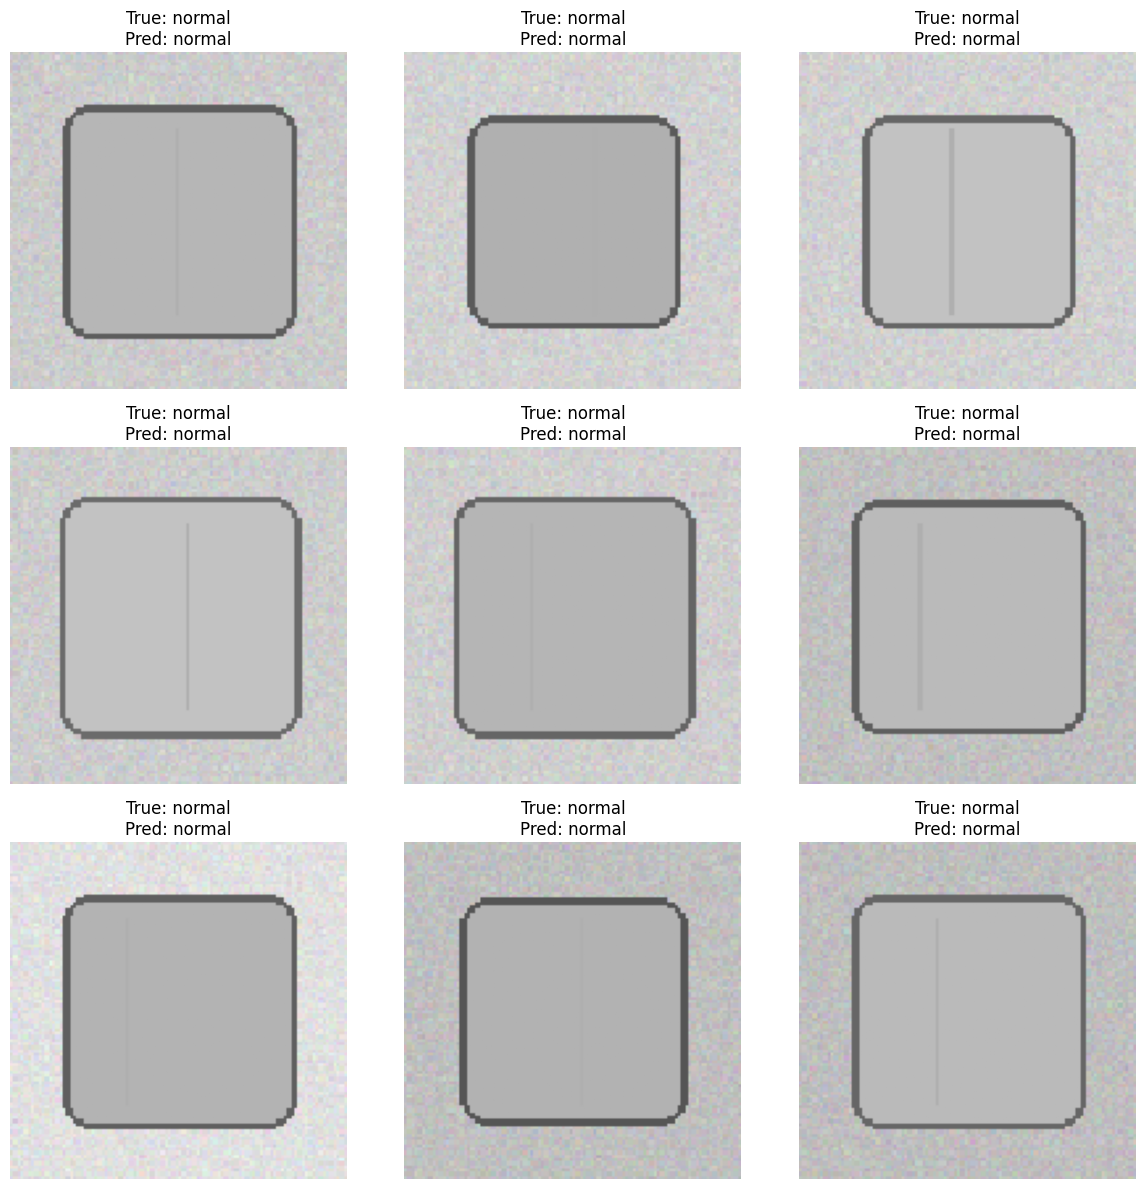

In [38]:
# Display sample predictions

import matplotlib.pyplot as plt

class_labels = list(validation_generator.class_indices.keys())

images, labels = next(validation_generator)

predictions = model.predict(images)

predicted_classes = np.argmax(predictions, axis=1)

true_classes = np.argmax(labels, axis=1)

plt.figure(figsize=(12, 12))

for i in range(9):

    

    plt.subplot(3, 3, i + 1)

    

    plt.imshow(images[i])

    

    plt.title(

        f"True: {class_labels[true_classes[i]]}\nPred: {class_labels[predicted_classes[i]]}"

    )

    

    plt.axis('off')

plt.tight_layout()
plt.savefig('sample_predictions/prediction_outputs.png')

plt.show()

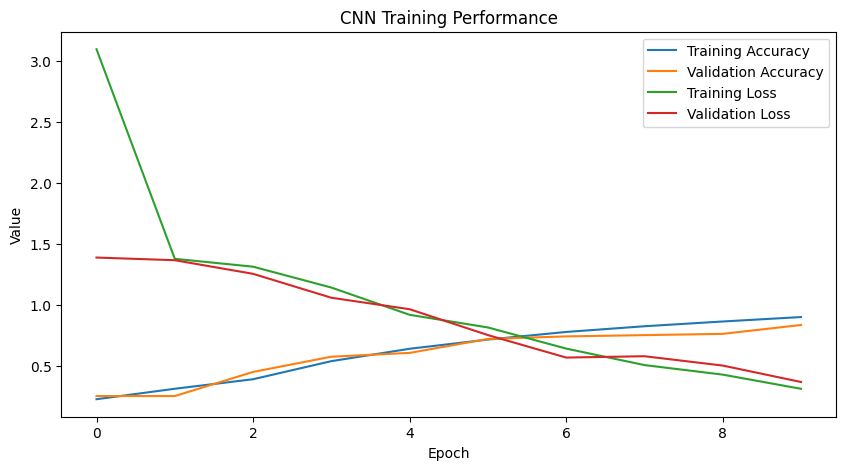

In [36]:
# Save accuracy and loss graph

plt.figure(figsize=(10,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')

plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.plot(history.history['loss'], label='Training Loss')

plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title('CNN Training Performance')

plt.xlabel('Epoch')

plt.ylabel('Value')

plt.legend()

plt.savefig('results/accuracy_loss_curves.png')

plt.show()

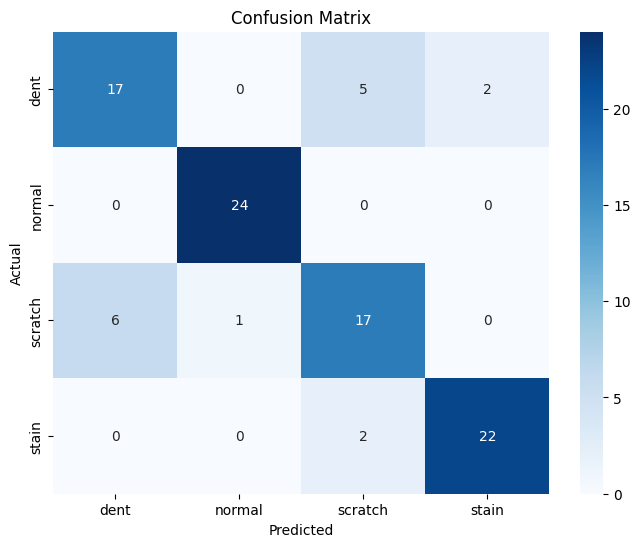

In [37]:
# Save confusion matrix image

import seaborn as sns

plt.figure(figsize=(8,6))

sns.heatmap(

    

    cm,

    

    annot=True,

    

    fmt='d',

    

    cmap='Blues',

    

    xticklabels=class_labels,

    

    yticklabels=class_labels

    

)

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.title('Confusion Matrix')

plt.savefig('results/confusion_matrix.png')

plt.show()